# Prueba Técnica para Científico de Datos

## EDA

In [1]:
import pandas as pd

In [2]:
train_data_file="./Data/data 1.xlsx"
df=pd.read_excel(train_data_file).copy()

In [3]:
df.head(3)

,ID,ind_malo,hora_reg_norm,dia_reg,medio_contacto_grupo,tipo_mail_rango,ingreso_propio_norm,edad_norm,sexo,nivel_estudios,...,con_2m_norm,BURO_DE_CREDITO_C,BANCO_C,KUBO_FINANCIERO_C,SIC_C,FINANCIERA_C,CONSUMIDOR_FINAL_C,MICROFINANCIERA_C,TIENDA_COMERCIAL_C,BANCOS_C
0,517534,0,0.434783,6,El Mejor Trato,hot,0.214286,0.006562,Mujer,Licenciatura,...,0.200000,0.277778,0.166667,0.055556,0.166667,0.111111,0.166667,0.0,0.055556,0.0
1,1143911,0,0.869565,3,Facebook,gma,0.089286,0.014639,Hombre,Maestria,...,0.266667,0.360000,0.320000,0.040000,0.040000,0.160000,0.040000,0.0,0.000000,0.0
2,1124994,0,0.956522,1,El Mejor Trato,gma,0.071429,0.016153,Hombre,Bachillerato,...,0.066667,0.111111,0.111111,0.111111,0.222222,0.000000,0.222222,0.0,0.222222,0.0


In [4]:
df.shape

(12660, 55)

In [5]:
df.columns

Index(['ID', 'ind_malo', 'hora_reg_norm', 'dia_reg', 'medio_contacto_grupo',
       'tipo_mail_rango', 'ingreso_propio_norm', 'edad_norm', 'sexo',
       'nivel_estudios', 'Estado', 'destino', 'act_eco', 'ing_cuota_pf_rv',
       'cuota_mensual_fijos', 'cuota_mensual_revolventes', 'hist_suf_pf_norm',
       'hist_suf_rv_norm', 'bc_score_norm', 'icc_norm', 'monto_prom_norm',
       'porc_deuda_12m_norm', 'porc_fijos_norm', 'porc_saldo_fijos_norm',
       'pagos_suf_limite_norm', 'pagos_suf_limite_RV_norm',
       'creditos_general_norm', 'creditos_general_ab_norm',
       'creditos_recientes_norm', 'Saldo_Vencido_act_norm',
       'Saldo_Actual_PF_norm', 'Saldo_Actual_RV_norm', 'porc_deuda_rev_norm',
       'pagos_suf_limite_PF_norm', 'porc_mop_1_norm', 'ind_mop_4_9_norm',
       'mop_max_act_norm', 'BANCO_HIP', 'BANCO_RV', 'BANCO_PF', 'AUTO',
       'TIENDA_COMERCIAL', 'FINANCIERA', 'MICROFINANCIERA', 'COMUNICACIONES',
       'con_2m_norm', 'BURO_DE_CREDITO_C', 'BANCO_C', 'KUBO_FINANCI

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12660 entries, 0 to 12659
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         12660 non-null  int64  
 1   ind_malo                   12660 non-null  int64  
 2   hora_reg_norm              12660 non-null  float64
 3   dia_reg                    12660 non-null  int64  
 4   medio_contacto_grupo       12660 non-null  object 
 5   tipo_mail_rango            12660 non-null  object 
 6   ingreso_propio_norm        12651 non-null  float64
 7   edad_norm                  12660 non-null  float64
 8   sexo                       12660 non-null  object 
 9   nivel_estudios             12660 non-null  object 
 10  Estado                     12660 non-null  object 
 11  destino                    12660 non-null  int64  
 12  act_eco                    12660 non-null  object 
 13  ing_cuota_pf_rv            12654 non-null  flo

In [7]:
#Imprimo algunos valores para entender las variables
for column in df.columns[0:]:
    print(column)
    print(df[column].unique()[0:15])
    print("")

ID
[ 517534 1143911 1124994  200051  528679  510836  338581  878873 1365465
 1736305  487905  200432 1963219  773772 1568136]

ind_malo
[0 1]

hora_reg_norm
[0.43478261 0.8695652  0.9565217  0.56521739 0.39130435 0.34782609
 0.5217391  0.86956522 0.         0.826087   0.91304348 0.82608696
 0.5652174  0.52173913 0.3478261 ]

dia_reg
[6 3 1 2 7 5 4]

medio_contacto_grupo
['El Mejor Trato' 'Facebook' 'Otro_medio' 'Campana GL' 'SOLCREDITO'
 'YoTePresto']

tipo_mail_rango
['hot' 'gma' 'out' 'yah' 'correo_otro']

ingreso_propio_norm
[0.21428571 0.08928571 0.07142857 0.125      0.05571429 0.05357143
 0.1607143  0.1785714  0.5535714  0.12857143 0.03214286 0.04464286
 0.3410714  0.25       0.09821429]

edad_norm
[0.00656234 0.01463907 0.01615346 0.01514387 0.00302877 0.00959112
 0.00504796 0.00403836 0.01211509 0.00706714 0.00302877 0.00807673
 0.00555275 0.01716305 0.01463907]

sexo
['Mujer' 'Hombre']

nivel_estudios
['Licenciatura' 'Maestria' 'Bachillerato' 'Secundaria' 'Doctorado'
 'Primari

In [8]:
#0 Si pagó, 1 no pagó
df["ind_malo"].value_counts(normalize=True)

ind_malo
0    0.788942
1    0.211058
Name: proportion, dtype: float64

In [9]:
null_valiues=df.isnull()
for column in null_valiues.columns:
    print(column)
    print(null_valiues[column].value_counts())
    print("")

ID
ID
False    12660
Name: count, dtype: int64

ind_malo
ind_malo
False    12660
Name: count, dtype: int64

hora_reg_norm
hora_reg_norm
False    12660
Name: count, dtype: int64

dia_reg
dia_reg
False    12660
Name: count, dtype: int64

medio_contacto_grupo
medio_contacto_grupo
False    12660
Name: count, dtype: int64

tipo_mail_rango
tipo_mail_rango
False    12660
Name: count, dtype: int64

ingreso_propio_norm
ingreso_propio_norm
False    12651
True         9
Name: count, dtype: int64

edad_norm
edad_norm
False    12660
Name: count, dtype: int64

sexo
sexo
False    12660
Name: count, dtype: int64

nivel_estudios
nivel_estudios
False    12660
Name: count, dtype: int64

Estado
Estado
False    12660
Name: count, dtype: int64

destino
destino
False    12660
Name: count, dtype: int64

act_eco
act_eco
False    12660
Name: count, dtype: int64

ing_cuota_pf_rv
ing_cuota_pf_rv
False    12654
True         6
Name: count, dtype: int64

cuota_mensual_fijos
cuota_mensual_fijos
False    12660
Name: c

Valores nulos son: ing_cuota_pf_rv
False    12654
True         6, ingreso_propio_norm
False    12651
True         9

Observo que ambas variables son continuas , entonces voy a llenar los valores nulos con la media

In [10]:
import numpy as np

In [11]:
df["ing_cuota_pf_rv"] = df["ing_cuota_pf_rv"].replace(np.nan,df["ing_cuota_pf_rv"].mean())

In [12]:
df["ingreso_propio_norm"] = df["ingreso_propio_norm"].replace(np.nan,df["ingreso_propio_norm"].mean())

In [13]:
null_valiues2=df.isnull()
print(null_valiues2["ing_cuota_pf_rv"].value_counts())
print(null_valiues2["ingreso_propio_norm"].value_counts())

ing_cuota_pf_rv
False    12660
Name: count, dtype: int64
ingreso_propio_norm
False    12660
Name: count, dtype: int64


Lo que haré es observar como es la correlacion de mis variables numéricas con mi variables objetivo que es ind_malo

In [14]:
correlaciones_check = df.corr(numeric_only=True)["ind_malo"].drop(["ind_malo", "ID"]).sort_values()

In [15]:
import matplotlib.pyplot as plt

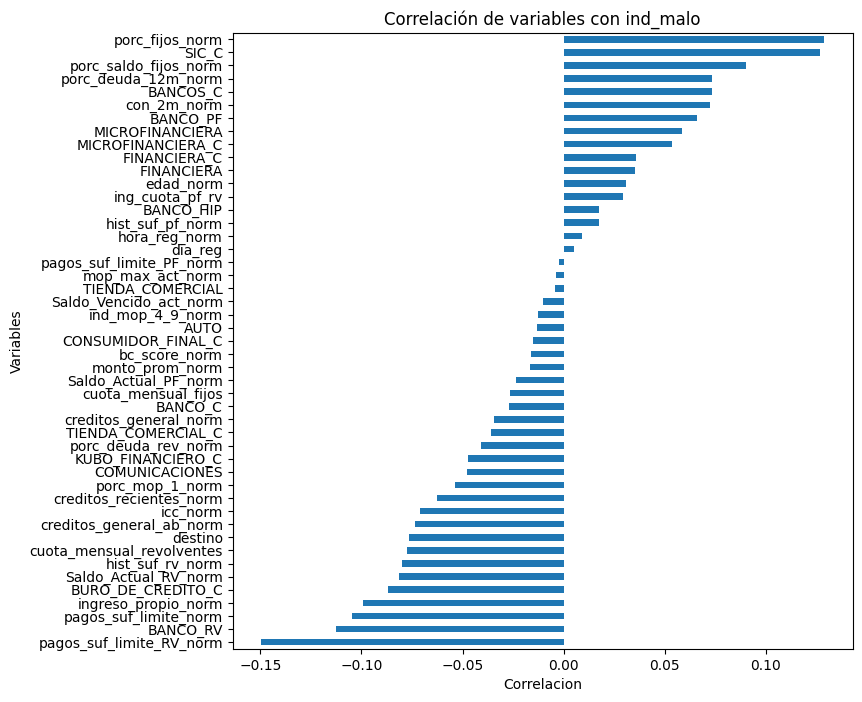

In [16]:
correlaciones_check.plot(kind="barh",figsize=(8,8))
plt.title("Correlación de variables con ind_malo")
plt.xlabel("Correlacion")
plt.ylabel("Variables")
plt.show()


Ahora hago un heatmap con las variables que mas se correlacionan , quito el signo solo para saber cuales son las variables con la mayor correlación

In [17]:
import seaborn as sns

cols_heatmap = correlaciones_check.abs().sort_values(ascending=False).head(5).index
cols_heatmap

Index(['pagos_suf_limite_RV_norm', 'porc_fijos_norm', 'SIC_C', 'BANCO_RV',
       'pagos_suf_limite_norm'],
      dtype='object')

In [18]:
#agrego la diagonal
cols_heatmap = ["ind_malo"] + list(cols_heatmap)

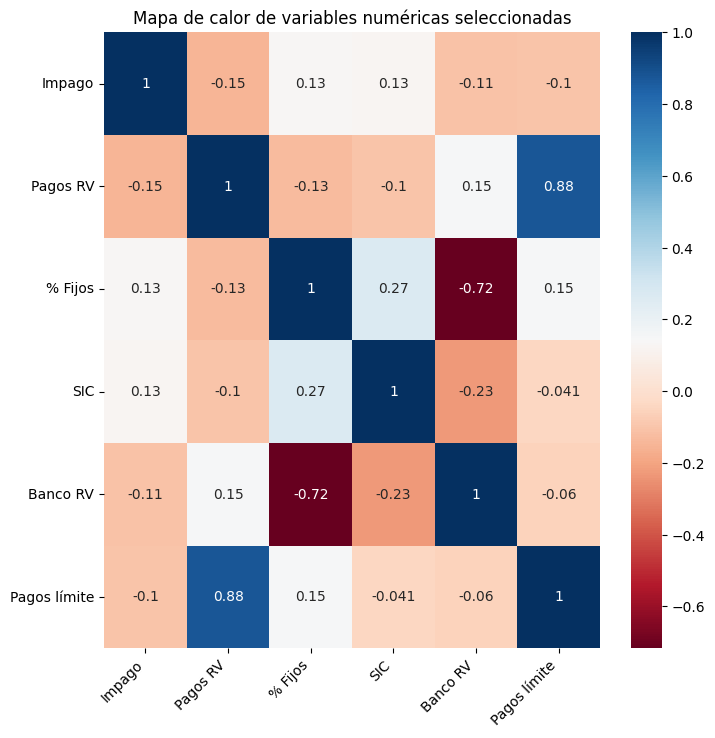

In [19]:
plt.figure(figsize=(8, 8))
labels_heatmap = ["Impago", "Pagos RV", "% Fijos", "SIC", "Banco RV", "Pagos límite"]
sns.heatmap(df[cols_heatmap].corr(), annot=True, cmap="RdBu", xticklabels=labels_heatmap, yticklabels=labels_heatmap)

plt.title("Mapa de calor de variables numéricas seleccionadas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("mapa_calor_correlaciones.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Modelado predictivo

In [20]:
X=df.drop(columns=["ID","ind_malo"])
X.head(2)
print(X.shape)

(12660, 53)


In [21]:
Y=df["ind_malo"]

Voy a buscar cuales son las variables categóricas

In [22]:
catego= df.select_dtypes(include="object").columns
print(catego)

Index(['medio_contacto_grupo', 'tipo_mail_rango', 'sexo', 'nivel_estudios',
       'Estado', 'act_eco'],
      dtype='object')


Voy a usar get dummies para convertir estas variables

In [23]:
X=pd.get_dummies(X)
 

In [24]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [25]:
X.shape

(12660, 101)

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12660 entries, 0 to 12659
Columns: 101 entries, hora_reg_norm to act_eco_Empleado
dtypes: bool(54), float64(43), int64(4)
memory usage: 5.2 MB


In [27]:
X.columns

Index(['hora_reg_norm', 'dia_reg', 'ingreso_propio_norm', 'edad_norm',
       'destino', 'ing_cuota_pf_rv', 'cuota_mensual_fijos',
       'cuota_mensual_revolventes', 'hist_suf_pf_norm', 'hist_suf_rv_norm',
       ...
       'Estado_Sinaloa', 'Estado_Sonora', 'Estado_Tabasco',
       'Estado_Tamaulipas', 'Estado_Tlaxcala', 'Estado_Veracruz Llave',
       'Estado_Yucatan', 'Estado_Zacatecas', 'act_eco_Comerciante',
       'act_eco_Empleado'],
      dtype='object', length=101)

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

## Modelo explicativo

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [31]:
#Hacemos nuestro pipeline
Input=[("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000))]
lr_pipeline = Pipeline(Input)

In [32]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000))])

In [33]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr= lr_pipeline.predict_proba(X_test)[:, 1]

In [34]:
#Evaluamos 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

In [35]:
print("accuracy=",accuracy_score(y_test, y_pred_lr))                #Porcentaje de predicciones correctas
print("precision=", precision_score(y_test, y_pred_lr)) #De los predichos como no pagados cuantos fueron no pagados realmente
print("recall=", recall_score(y_test, y_pred_lr))       #De todos los creditos malos cuantos detectamos
print("f1score=", f1_score(y_test, y_pred_lr))         # Mix de recall y  precisison
print("rocauc=", roc_auc_score(y_test, y_prob_lr))     # que tan bien es el modelo en separar buenos pagadores de malos pagadores

accuracy= 0.7879146919431279
precision= 0.4835164835164835
recall= 0.08239700374531835
f1score= 0.1408
rocauc= 0.6857859732391567


In [36]:
print(confusion_matrix(y_test, y_pred_lr))

[[1951   47]
 [ 490   44]]


Aunque el modelo obtiene un accuracy de 0.7879, este resultado puede ser engañoso debido al desbalance que hay entre los dos tipos de cleintes el cual es de 78.9% de los créditos corresponden a clientes que sí pagaron. La matriz de confusión muestra que el modelo clasifica correctamente 1951 créditos buenos, pero solo detecta 44 de los 534 creditos de los no pagadores. Esto se refleja en la metrica recall de 0.0824, lo que significa que el modelo identifica únicamente el 8.24% de los no pagadores reales, esto en mi criterio es pésimo. Entonces, se entrenará una versión balanceada del modelo para dar mayor peso a la clase minoritaria y mejorar la detección de posibles impagos.

In [37]:
#Lo mismo que el caso anterior
Input2=[("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000, class_weight="balanced"))]
lr_pipeline_balanced = Pipeline(Input2)
lr_pipeline_balanced.fit(X_train, y_train)
y_pred_lr_balanced = lr_pipeline_balanced.predict(X_test)
y_prob_lr_balanced = lr_pipeline_balanced.predict_proba(X_test)[:, 1]

In [38]:
print("accuracy=", accuracy_score(y_test, y_pred_lr_balanced))
print("precision=", precision_score(y_test, y_pred_lr_balanced))
print("recall=", recall_score(y_test, y_pred_lr_balanced))
print("f1score=", f1_score(y_test, y_pred_lr_balanced))
print("rocauc=", roc_auc_score(y_test, y_prob_lr_balanced))

accuracy= 0.6571879936808847
precision= 0.33399602385685884
recall= 0.6292134831460674
f1score= 0.43636363636363634
rocauc= 0.6855188521855188


In [39]:
print(confusion_matrix(y_test, y_pred_lr_balanced))

[[1328  670]
 [ 198  336]]


Al usar el balanced, obtenemos diferencias significativas en las métricas. El accuracy baja de aproximadamente 0.79 a 0.66, pero el recall del cleinte 1 mejora de forma importante: pasa de 0.08 a 0.63. Esto significa que el modelo balanceado detecta 336 de los 534 créditos malos, mientras que el modelo anterior solo detectaba 44, esto es una muy buena mejora. La matriz de confusión nos dice que ahora se reducen los falsos negativos de 490 a 198, esto nuevamente es bueno ya que en este problema de riesgo crediticio los falsos negativos representan clientes que no pagaron pero fueron clasificados como buenos. Aparece un problema ya que aumentan los falsos positivos de 47 a 670, es decir, más clientes buenos son clasificados como riesgosos. Por lo tanto, el modelo balanceado es más adecuado si el objetivo principal es detectar una mayor proporción de posibles impagos, aunque se acepte una mayor cantidad de alertas falsas.

## Modelo no explicativo

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
# usamos un Random Forest balanceado
rf_model = RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced")

In [42]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [43]:
#Evaluamos igual
print("sccuracy=", accuracy_score(y_test, y_pred_rf))
print("Precision_clase_1=", precision_score(y_test, y_pred_rf))
print("Recall_clase_1=", recall_score(y_test, y_pred_rf))
print("f1score_clase_1=", f1_score(y_test, y_pred_rf))
print("rocauc=", roc_auc_score(y_test, y_prob_rf))

sccuracy= 0.7938388625592417
Precision_clase_1= 0.7307692307692307
Recall_clase_1= 0.035580524344569285
f1score_clase_1= 0.06785714285714285
rocauc= 0.7035504605729326


In [44]:
print(confusion_matrix(y_test, y_pred_rf))

[[1991    7]
 [ 515   19]]


El random forest resultad en un accuracy de 0.79 y un roc auc de 0.70, su recall para la clase 1 es muy bajo. El modelo solo detecta 19 de 534 clientes con posible impago, entonces clasifica casi todos los casos como clase 0.

## Conclusion de los modelos

Aunque el random forest obtiene mayor accuracy y un rocauc un poco mayor, su recall para la clase 1 demasiado bajo. El modelo solo detecta 19 de 534 clientes con posible impago. Como el objetivo principal del problema es identificar clientes que podrían no pagar, se selecciona la regresión logística balanceada como modelo final, ya que detecta mejor cuales clientes serán impagos.

# Data to predict

In [45]:
predict_data_file="./Data/data_to_predict 1.xlsx"
dfPre=pd.read_excel(predict_data_file).copy()

In [46]:
dfPre.head(3)

,ID,hora_reg_norm,dia_reg,medio_contacto_grupo,tipo_mail_rango,ingreso_propio_norm,edad_norm,sexo,nivel_estudios,Estado,...,con_2m_norm,BURO_DE_CREDITO_C,BANCO_C,KUBO_FINANCIERO_C,SIC_C,FINANCIERA_C,CONSUMIDOR_FINAL_C,MICROFINANCIERA_C,TIENDA_COMERCIAL_C,BANCOS_C
0,411103,0.826087,4,El Mejor Trato,hot,0.000000,0.004543,Hombre,Secundaria,CDMX,...,0.066667,0.400000,0.200000,0.200000,0.0,0.200000,0.0,0.0,0.0,0.0
1,244797,0.695652,2,El Mejor Trato,hot,0.053571,0.011106,Hombre,Bachillerato,Nuevo Leon,...,0.133333,0.333333,0.222222,0.222222,0.0,0.222222,0.0,0.0,0.0,0.0
2,1622767,0.826087,7,Campana GL,gma,0.196429,0.004038,Mujer,Licenciatura,Quintana Roo,...,0.266667,0.428571,0.142857,0.142857,0.0,0.142857,0.0,0.0,0.0,0.0


In [47]:
null_valiuesPre=dfPre.isnull()
for column in null_valiuesPre.columns:
    print(column)
    print(null_valiuesPre[column].value_counts())
    print("")

ID
ID
False    1407
Name: count, dtype: int64

hora_reg_norm
hora_reg_norm
False    1407
Name: count, dtype: int64

dia_reg
dia_reg
False    1407
Name: count, dtype: int64

medio_contacto_grupo
medio_contacto_grupo
False    1407
Name: count, dtype: int64

tipo_mail_rango
tipo_mail_rango
False    1407
Name: count, dtype: int64

ingreso_propio_norm
ingreso_propio_norm
False    1407
Name: count, dtype: int64

edad_norm
edad_norm
False    1407
Name: count, dtype: int64

sexo
sexo
False    1407
Name: count, dtype: int64

nivel_estudios
nivel_estudios
False    1407
Name: count, dtype: int64

Estado
Estado
False    1407
Name: count, dtype: int64

destino
destino
False    1407
Name: count, dtype: int64

act_eco
act_eco
False    1407
Name: count, dtype: int64

ing_cuota_pf_rv
ing_cuota_pf_rv
False    1407
Name: count, dtype: int64

cuota_mensual_fijos
cuota_mensual_fijos
False    1407
Name: count, dtype: int64

cuota_mensual_revolventes
cuota_mensual_revolventes
False    1407
Name: count, dtype

In [48]:
#Ahora preparamos variables
idsPre = dfPre["ID"]
XPre = dfPre.drop(columns=["ID"])

In [49]:
XPre.head(3)

,hora_reg_norm,dia_reg,medio_contacto_grupo,tipo_mail_rango,ingreso_propio_norm,edad_norm,sexo,nivel_estudios,Estado,destino,...,con_2m_norm,BURO_DE_CREDITO_C,BANCO_C,KUBO_FINANCIERO_C,SIC_C,FINANCIERA_C,CONSUMIDOR_FINAL_C,MICROFINANCIERA_C,TIENDA_COMERCIAL_C,BANCOS_C
0,0.826087,4,El Mejor Trato,hot,0.000000,0.004543,Hombre,Secundaria,CDMX,3,...,0.066667,0.400000,0.200000,0.200000,0.0,0.200000,0.0,0.0,0.0,0.0
1,0.695652,2,El Mejor Trato,hot,0.053571,0.011106,Hombre,Bachillerato,Nuevo Leon,1,...,0.133333,0.333333,0.222222,0.222222,0.0,0.222222,0.0,0.0,0.0,0.0
2,0.826087,7,Campana GL,gma,0.196429,0.004038,Mujer,Licenciatura,Quintana Roo,10,...,0.266667,0.428571,0.142857,0.142857,0.0,0.142857,0.0,0.0,0.0,0.0


In [50]:
XPre.shape

(1407, 53)

In [51]:
XPre = pd.get_dummies(XPre)

In [52]:
XPre.shape

(1407, 100)

In [53]:
XPre = XPre.reindex(columns=X.columns, fill_value=0)

In [54]:
XPre.shape

(1407, 101)

In [55]:
#prediccion
predict = lr_pipeline_balanced.predict(XPre)
predict 

array([1, 0, 0, ..., 0, 0, 0])

In [56]:
# archivo para exportar
FinalPre = pd.DataFrame({"ID": idsPre, "ind_malo_predicted": predict})
FinalPre.head(5)

,ID,ind_malo_predicted
0,411103,1
1,244797,0
2,1622767,0
3,1904144,1
4,90897,1


In [57]:
FinalPre["ind_malo_predicted"].value_counts(normalize=True)

ind_malo_predicted
0    0.606965
1    0.393035
Name: proportion, dtype: float64

In [58]:
FinalPre.to_csv("predicciones_OscarCarranzaJimenez.csv", index=False)

# Autor: Oscar Carranza Jiménez

<img src="OscarFeynmanLogo.png" width="200">